
# Vanishing Gradient en RNNs básicas

En este cuaderno reutilizamos las rutinas de RNN_signal_wandb para generar señales trigonométricas, entrenar una RNN simple y estudiar la caída del gradiente cuando aumentamos la longitud de la secuencia.



## Configuración y librerías

Cargamos los paquetes necesarios y fijamos semillas para garantizar reproducibilidad.


In [18]:
import numpy as np
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.metrics import mean_squared_error

torch.manual_seed(0)
np.random.seed(0)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usaremos el dispositivo: {device}")

Usaremos el dispositivo: cuda



## Parámetros globales

Definimos un largo de secuencia por defecto y constantes auxiliares que utilizaremos en todo el análisis.


In [19]:
DEFAULT_SEQ_LEN = 50  # número de muestras del pasado (contexto) a usar por defecto
N_FUTURE = 1        # predicciones a futuro
TOTAL_SAMPLES = 10000
BATCH_SIZE = 64
EPOCHS = 12
print(f"Contexto base configurado en {DEFAULT_SEQ_LEN} pasos")

Contexto base configurado en 50 pasos



## Funciones compartidas con RNN_signal_wandb

Copiamos exactamente las funciones utilitarias empleadas en el notebook original para garantizar el mismo flujo de datos y entrenamiento.


In [20]:
# Funcion para generar base de datos de señales
def generate_time_series(batch_size, n_steps, n_future):
    freq1, freq2, offsets1, offsets2 = np.random.rand(4, batch_size, 1)
    time = np.linspace(0, 1, n_steps + n_future)
    series = 0.5 * np.sin((time - offsets1) * (freq1 * 10 + 10))  #   wave 1
    series += 0.2 * np.sin((time - offsets2) * (freq2 * 20 + 20)) # + wave 2
    series += 0.1 * (np.random.rand(batch_size, n_steps + n_future) - 0.5)   # + noise
    return series[..., np.newaxis].astype(np.float32)

In [21]:
# función que plotea un array de curvas (inputs y outputs)
def plot_series(series, y=None, y_pred=None, y_pred_std=None, x_label="$", y_label="$"):
  # si tengo profundidad de mi serie temporal, me quedo solamente con la 1ra.
  series = series[:,:,0]
  r, c = 3, 5
  fig, axes = plt.subplots(nrows=r, ncols=c, sharey=True, sharex=True, figsize=(20, 10))
  for row in range(r):
    for col in range(c):
        plt.sca(axes[row][col])
        ix = col + row*c
        plt.plot(series[ix, :], ".-")
        if y is not None:
            plt.plot(range(len(series[ix, :]), len(series[ix, :])+len(y[ix])), y[ix], "bx", markersize=10)
        if y_pred is not None:
            plt.plot(range(len(series[ix, :]), len(series[ix, :])+len(y_pred[ix])), y_pred[ix], "ro")
        if y_pred_std is not None:
            plt.plot(range(len(series[ix, :]), len(series[ix, :])+len(y_pred[ix])), y_pred[ix] + y_pred_std[ix])
            plt.plot(range(len(series[ix, :]), len(series[ix, :])+len(y_pred[ix])), y_pred[ix] - y_pred_std[ix])
        plt.grid(True)
        plt.hlines(0, 0, 100, linewidth=1)
        if y is not None:
            max_len = len(series[ix, :]) + len(y[ix])
        else:
            max_len = len(series[ix, :])
        plt.axis([0, max_len, -1, 1])
        if x_label and row == r - 1:
          plt.xlabel(x_label, fontsize=16)
        if y_label and col == 0:
          plt.ylabel(y_label, fontsize=16, rotation=0)
  plt.show()

In [22]:
# Clase dataset para luego armar los dataloader
class TimeSeriesDataset(Dataset):
  def __init__(self, X, y=None, train=True):
    self.X = X
    self.y = y
    self.train = train

  def __len__(self):
    return len(self.X)

  def __getitem__(self, ix):
    if self.train:
      return torch.from_numpy(self.X[ix]), torch.from_numpy(self.y[ix])
    return torch.from_numpy(self.X[ix]) # si no es train, solo devuelve el X

In [23]:
# funciones de entrenamiento
def fit(model, dataloader, epochs=10):
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = torch.nn.MSELoss()

    for epoch in range(epochs+1):
        print("epoch numero: ", epoch)
        bar = tqdm(dataloader['train'])
        model.train()
        train_loss = []
        eval_loss = []
        for batch in bar:
            X, y = batch
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()
            y_hat = model(X)
            y = y.view(y.shape[0], -1) # aca elimino la dim de la profundidad
            loss = criterion(y_hat, y)
            loss.backward()
            optimizer.step()
            train_loss.append(loss.item())
            bar.set_description(f"train_loss {np.mean(train_loss):.5f}")

        bar = tqdm(dataloader['eval'])
        model.eval()

        with torch.no_grad():
            for batch in bar:
                X, y = batch
                X, y = X.to(device), y.to(device)
                y_hat = model(X)
                y = y.view(y.shape[0], -1)
                loss = criterion(y_hat, y)
                eval_loss.append(loss.item())
                bar.set_description(f"valid_loss {np.mean(eval_loss):.5f}")

def predict(model, dataloader, reduced=0):
    model.eval()
    with torch.no_grad():
        preds = torch.tensor([]).to(device)
        primera = 0
        for batch in dataloader:
            X = batch
            X = X[:,-reduced:,:] # el argumento reduced toma las últimas 'reduced' muestras
            if primera == 0:
              print('X shape empleado para predecir: ')
              print(X.shape)
              primera = 1
            X = X.to(device)
            pred = model(X)
            preds = torch.cat([preds, pred])
        return preds

## Preparación del dataset

Generamos 10 000 señales, reservamos 70 % para entrenamiento, 20 % para validación y 10 % para prueba, igual que en RNN_signal_wandb.


In [24]:
def prepare_dataset(n_steps, total_samples=TOTAL_SAMPLES, batch_size=BATCH_SIZE, verbose=True):
    series = generate_time_series(total_samples, n_steps, N_FUTURE)
    X_train, y_train = series[:7000, :n_steps], series[:7000, -N_FUTURE:]
    X_valid, y_valid = series[7000:9000, :n_steps], series[7000:9000, -N_FUTURE:]
    X_test, y_test = series[9000:, :n_steps], series[9000:, -N_FUTURE:]

    if verbose:
        print('X and y Train shape')
        print(X_train.shape, y_train.shape)
        print('X and y Valid shape')
        print(X_valid.shape, y_valid.shape)
        print('X and y Test shape')
        print(X_test.shape, y_test.shape)

    dataset = {
        'train': TimeSeriesDataset(X_train, y_train),
        'eval': TimeSeriesDataset(X_valid, y_valid),
        'test': TimeSeriesDataset(X_test, y_test, train=False)
    }

    dataloader = {
        'train': DataLoader(dataset['train'], shuffle=True, batch_size=batch_size),
        'eval': DataLoader(dataset['eval'], shuffle=False, batch_size=batch_size),
        'test': DataLoader(dataset['test'], shuffle=False, batch_size=batch_size)
    }

    arrays = {
        'X_train': X_train,
        'y_train': y_train,
        'X_valid': X_valid,
        'y_valid': y_valid,
        'X_test': X_test,
        'y_test': y_test
    }

    return dataset, dataloader, arrays

X and y Train shape
(7000, 50, 1) (7000, 1, 1)
X and y Valid shape
(2000, 50, 1) (2000, 1, 1)
X and y Test shape
(1000, 50, 1) (1000, 1, 1)


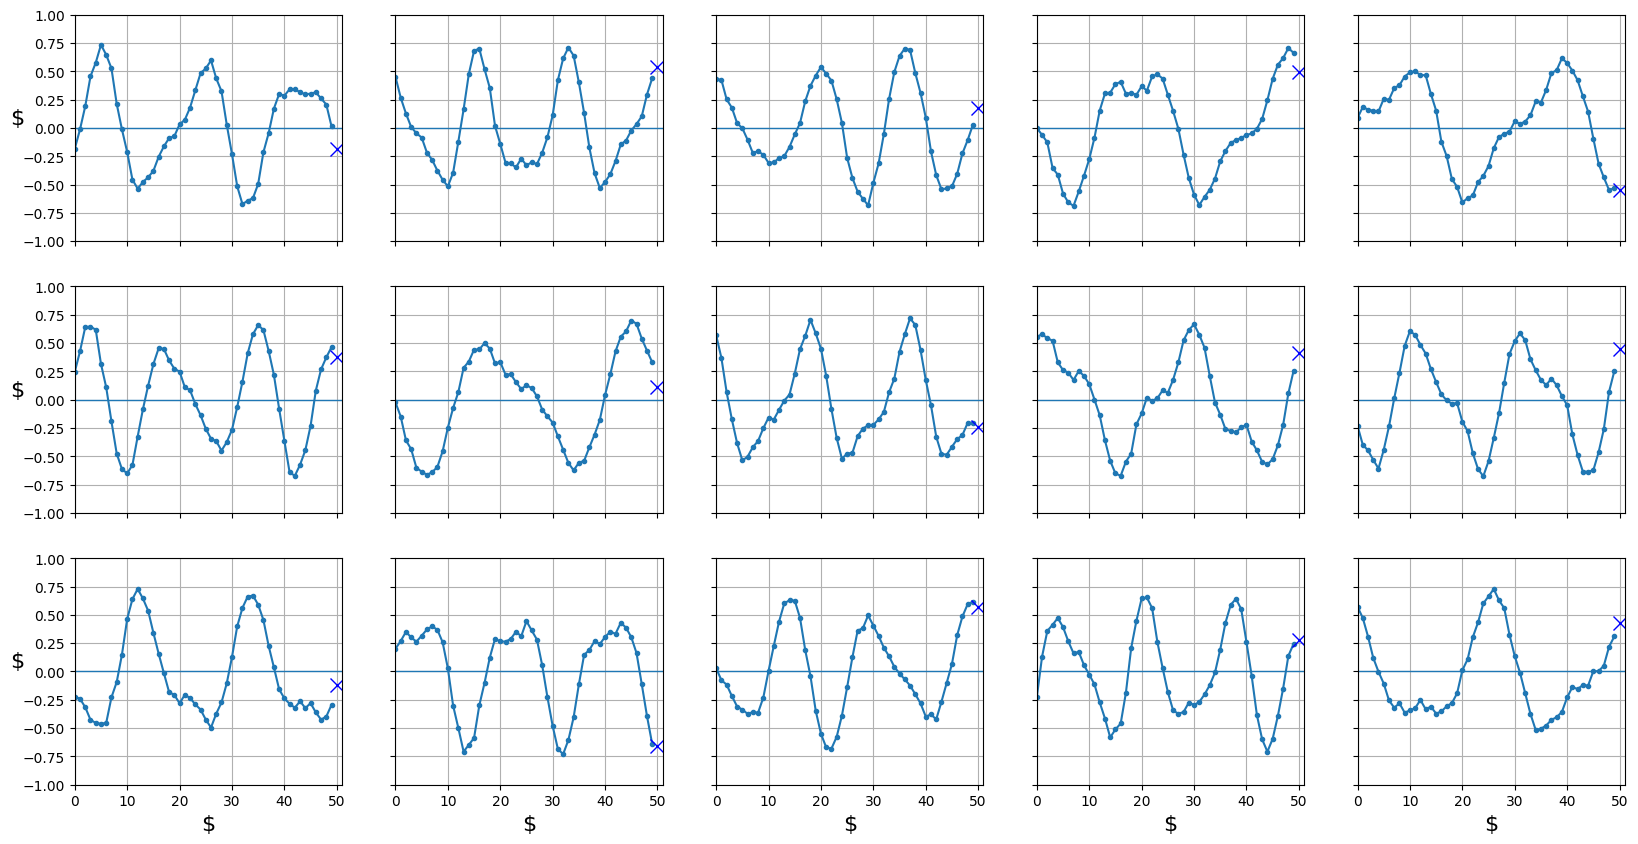

In [25]:
dataset_base, dataloader_base, arrays_base = prepare_dataset(DEFAULT_SEQ_LEN)
plot_series(arrays_base['X_test'], arrays_base['y_test'])

## Modelo RNN

Usamos la misma arquitectura simple (RNN 	anh + capa lineal) que acompaña a las funciones anteriores, pero permitiendo pasar un estado inicial opcional para los experimentos de gradiente.


In [26]:
class SimpleRNNRegressor(nn.Module):
    def __init__(self, input_size=1, hidden_size=32, num_layers=1, n_out=1, activation='tanh'):
        super().__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.activation = activation
        self.rnn = nn.RNN(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            nonlinearity=activation,
            batch_first=True
        )
        self.readout = nn.Linear(hidden_size, n_out)

    def forward(self, x, h0=None):
        rnn_out, _ = self.rnn(x, h0)
        last_hidden = rnn_out[:, -1, :]
        return self.readout(last_hidden)


## Entrenamiento base con el contexto global

Entrenamos la red usando it y registramos el error cuadrático medio (MSE) en el conjunto de prueba.


In [27]:
def train_context(seq_len, epochs=EPOCHS):
    dataset, dataloader, arrays = prepare_dataset(seq_len, batch_size=BATCH_SIZE, verbose=False)
    model = SimpleRNNRegressor(input_size=1, hidden_size=32, num_layers=2, n_out=N_FUTURE)
    fit(model, dataloader, epochs=epochs)
    y_pred = predict(model, dataloader['test'], reduced=0).cpu().numpy()
    mse = mean_squared_error(np.squeeze(arrays['y_test']), np.squeeze(y_pred))
    return {
        'seq_len': seq_len,
        'model': model,
        'dataloader': dataloader,
        'arrays': arrays,
        'mse': mse
    }

experiment_base = train_context(DEFAULT_SEQ_LEN)
print(f"MSE en test para {experiment_base['seq_len']} pasos: {experiment_base['mse']:.6f}")

epoch numero:  0


  0%|          | 0/110 [00:00<?, ?it/s]

valid_loss 0.00673: 100%|██████████| 32/32 [00:00<00:00, 650.65it/s]


epoch numero:  1


valid_loss 0.00520: 100%|██████████| 32/32 [00:00<00:00, 604.12it/s]


...

epoch numero:  11


valid_loss 0.00344: 100%|██████████| 32/32 [00:00<00:00, 514.69it/s]


epoch numero:  12


valid_loss 0.00334: 100%|██████████| 32/32 [00:00<00:00, 473.64it/s]

X shape empleado para predecir: 
torch.Size([64, 50, 1])
MSE en test para 50 pasos: 0.003261


## Experimento de gradientes con comentarios paso a paso

Medimos cómo se atenúan los gradientes de los pesos recurrentes (W_hh) y del estado inicial (h0) al variar la longitud de la secuencia. La función replica la lógica del notebook original pero añade comentarios detallados.


In [33]:
def gradient_decay_experiment(model, seq_lengths, repeats=5, batch_size=BATCH_SIZE, noise=0.02):
    """Evalúa la norma del gradiente para distintas longitudes de secuencia."""
    stats = []
    criterion = nn.MSELoss()
    was_training = model.training
    model.train()  # habilitamos autograd completo
    try:
        with torch.backends.cudnn.flags(enabled=False): # deshabilitamos cudnn para evitar optimizaciones que podrían afectar el cálculo de gradientes
            for seq_len in seq_lengths:
                weight_norms = []
                h0_norms = []
                for _ in range(repeats):
                    # 1) Generamos un lote sintético con la longitud solicitada.
                    batch = generate_time_series(batch_size, seq_len, N_FUTURE)
                    X = torch.from_numpy(batch[:, :seq_len, :]).to(device)
                    y = torch.from_numpy(batch[:, -N_FUTURE:, :]).to(device)

                    # 2) Estado inicial con gradiente para medir qué tan lejos viaja la señal de error.
                    h0 = torch.zeros(model.num_layers, batch_size, model.hidden_size, device=device, requires_grad=True)

                    # 3) Forward + backward manual.
                    preds = model(X, h0=h0)
                    loss = criterion(preds, y.view(y.shape[0], -1))
                    loss.backward()

                    # 4) Guardamos las normas y limpiamos.
                    weight_norms.append(model.rnn.weight_hh_l0.grad.detach().norm().item())
                    h0_norms.append(h0.grad.detach().norm().item())
                    model.zero_grad(set_to_none=True)
                stats.append({
                    'seq_len': seq_len,
                    'weight_grad_norm': float(np.mean(weight_norms)), # valor medio para las repeticiones
                    'h0_grad_norm': float(np.mean(h0_norms)) # valor medio para las repeticiones
                })
    finally:
        if not was_training:
            model.eval()
    return stats

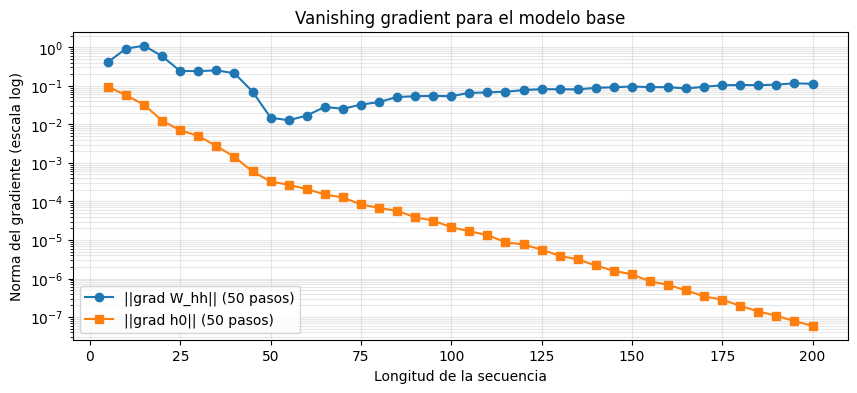

Contexto sugerido por el quiebre: 35 pasos (threshold 4.76e-03)


In [ ]:
seq_lengths = list(range(5, 205, 5)) # evaluamos cada 5 pasos hasta 200
grad_stats = gradient_decay_experiment(experiment_base['model'], seq_lengths, repeats=5, batch_size=BATCH_SIZE)

lengths = [row['seq_len'] for row in grad_stats]
weight_norms = [row['weight_grad_norm'] for row in grad_stats]
h0_norms = [row['h0_grad_norm'] for row in grad_stats]

plt.figure(figsize=(10, 4))
plt.plot(lengths, weight_norms, marker='o', label='||grad W_hh|| (50 pasos)')
plt.plot(lengths, h0_norms, marker='s', label='||grad h0|| (50 pasos)')
plt.yscale('log')
plt.xlabel('Longitud de la secuencia')
plt.ylabel('Norma del gradiente (escala log)')
plt.title('Vanishing gradient para el modelo base')
plt.grid(True, which='both', alpha=0.3)
plt.legend()
plt.show()

# definimos un umbral de quiebre como un porcentaje de la norma del gradiente para el contexto base (50 pasos)
break_threshold = max(h0_norms[0] * 0.05, 1e-3)
short_context = DEFAULT_SEQ_LEN
for row in grad_stats:
    if row['h0_grad_norm'] <= break_threshold:
        short_context = row['seq_len']
        break

print(f"Contexto sugerido por el quiebre: {short_context} pasos (threshold {break_threshold:.2e})")
if short_context >= DEFAULT_SEQ_LEN:
    print('No se detectó un quiebre antes del contexto base; se reutilizará el largo original.')

## Reentrenamiento con el contexto acotado

Volvemos a entrenar la misma RNN pero limitando la secuencia al largo donde el gradiente comienza a desvanecerse y comparamos los MSE obtenidos.


In [35]:
experiment_short = train_context(short_context)
print(f"MSE en test para {experiment_short['seq_len']} pasos: {experiment_short['mse']:.6f}")
print(f"Comparación directa -> ΔMSE = {experiment_short['mse'] - experiment_base['mse']:.6f}")

epoch numero:  0


valid_loss 0.01329: 100%|██████████| 32/32 [00:00<00:00, 384.23it/s]


epoch numero:  1


valid_loss 0.00724: 100%|██████████| 32/32 [00:00<00:00, 519.51it/s]


epoch numero:  2


...

epoch numero:  11


valid_loss 0.00401: 100%|██████████| 32/32 [00:00<00:00, 487.57it/s]


epoch numero:  12


valid_loss 0.00418: 100%|██████████| 32/32 [00:00<00:00, 464.38it/s]

X shape empleado para predecir: 
torch.Size([64, 35, 1])
MSE en test para 35 pasos: 0.004059
Comparación directa -> ΔMSE = 0.000798


## Gradientes del modelo corto vs. modelo base

Repetimos el experimento de gradientes para el modelo recortado y superponemos ambas curvas.


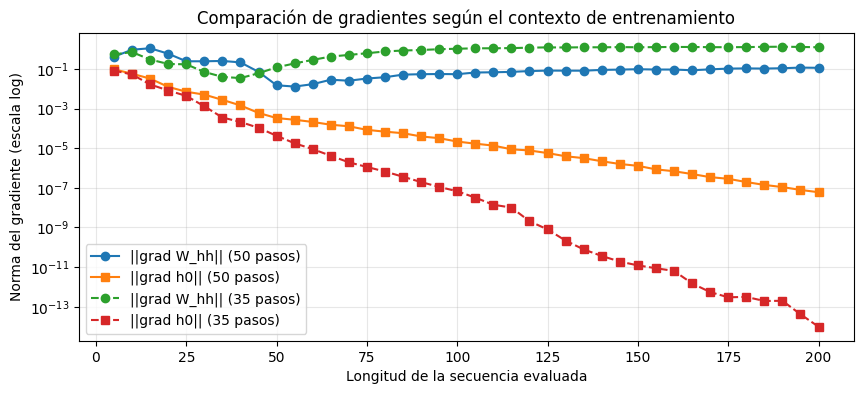

Resumen del modelo corto:
L=  5 -> ||grad W_hh||=5.40e-01 | ||grad h0||=8.18e-02
L= 30 -> ||grad W_hh||=6.99e-02 | ||grad h0||=1.29e-03
L= 55 -> ||grad W_hh||=1.88e-01 | ||grad h0||=1.75e-05
L= 80 -> ||grad W_hh||=7.55e-01 | ||grad h0||=6.61e-07
L=105 -> ||grad W_hh||=1.09e+00 | ||grad h0||=3.17e-08
L=130 -> ||grad W_hh||=1.20e+00 | ||grad h0||=2.15e-10
L=155 -> ||grad W_hh||=1.25e+00 | ||grad h0||=8.68e-12
L=180 -> ||grad W_hh||=1.26e+00 | ||grad h0||=3.11e-13


In [36]:
grad_stats_short = gradient_decay_experiment(experiment_short['model'], seq_lengths, repeats=5, batch_size=256)

weight_norms_short = [row['weight_grad_norm'] for row in grad_stats_short]
h0_norms_short = [row['h0_grad_norm'] for row in grad_stats_short]

plt.figure(figsize=(10, 4))
plt.plot(lengths, weight_norms, 'o-', label='||grad W_hh|| (50 pasos)')
plt.plot(lengths, h0_norms, 's-', label='||grad h0|| (50 pasos)')
plt.plot(lengths, weight_norms_short, 'o--', label=f"||grad W_hh|| ({short_context} pasos)")
plt.plot(lengths, h0_norms_short, 's--', label=f"||grad h0|| ({short_context} pasos)")
plt.yscale('log')
plt.xlabel('Longitud de la secuencia evaluada')
plt.ylabel('Norma del gradiente (escala log)')
plt.title('Comparación de gradientes según el contexto de entrenamiento')
plt.grid(True, which='both', alpha=0.3)
plt.legend(loc='lower left')
plt.show()

print('Resumen del modelo corto:')
for row in grad_stats_short[::5]:
    print(f"L={row['seq_len']:>3} -> ||grad W_hh||={row['weight_grad_norm']:.2e} | ||grad h0||={row['h0_grad_norm']:.2e}")

### Observaciones finales


- El gradiente del estado inicial cae varias órdenes de magnitud pasada cierta longitud; acotar el contexto evita procesar información que no aporta señal de error.
- La comparación de MSE ayuda a decidir si la reducción del contexto impacta en la precisión o solo mejora la eficiencia.
- Si el problema requiere dependencias más largas, conviene pasar a arquitecturas con mecanismos de gating (GRU/LSTM) o usar normalizaciones/residual connections que mitiguen el vanishing gradient.
